In [64]:

import pandas as pd
import matplotlib.pyplot as plt
# to encode physical activity
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
# to encode Occupation
from sklearn.preprocessing import OneHotEncoder

#for training(regression model)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

data = pd.read_csv("mental_health.csv")
print(data)


      Person_ID  Age  Gender  Occupation  Daily_Screen_Time  \
0             1   54    Male     Student               10.2   
1             2   44    Male     Student                6.8   
2             3   30    Male    Employed                5.5   
3             4   58    Male    Employed                5.6   
4             5   23  Female    Employed               10.1   
...         ...  ...     ...         ...                ...   
1995       1996   49  Female    Employed                4.8   
1996       1997   33    Male    Employed                2.7   
1997       1998   28    Male    Employed                2.6   
1998       1999   56  Female     Student                3.2   
1999       2000   38    Male  Unemployed                7.8   

      Social_Media_Usage  Night_Usage  Sleep_Hours  Stress_Level  \
0                    7.5            0          6.5             8   
1                    4.5            0          5.1             4   
2                    6.9            0  

In [65]:
important_attributes = []
for i in data.columns:
    important_attributes.append(i)
    #print(i)


''' Things to remove in the dataset
- Anxiety
- caffeine_Intake
- gender
- person id
- depression
- smoking
- alcohol
'''

# removing unnecessary attributes
important_attributes.remove("Person_ID")
important_attributes.remove("Gender")
important_attributes.remove("Anxiety")
important_attributes.remove("Alcohol")
important_attributes.remove("Smoking")
important_attributes.remove("Caffeine_Intake")

for important_data in important_attributes:
    print(important_data)

Age
Occupation
Daily_Screen_Time
Social_Media_Usage
Night_Usage
Sleep_Hours
Stress_Level
Work_Study_Hours
Physical_Activity
Social_Interaction_Score
Depression
Burnout


In [66]:
# data cleaning
def data_cleaning(data):
    data = data.drop(columns=["Person_ID", "Gender", "Anxiety", "Alcohol", "Smoking", "Caffeine_Intake"])
    data = data.drop_duplicates()
    return data

data = data_cleaning(data)

#analysis
# x-axis
sleep_hour = data["Sleep_Hours"].head(50)
work_study_hours= data["Work_Study_Hours"].head(50)
social_interaction_score = data["Social_Interaction_Score"].head(50)
burnout = data["Burnout"].head(50)
physical_activity = data["Physical_Activity"].head(50)
depression = data["Depression"].head(50)
night_usage = data["Night_Usage"].head(50)
age = data["Age"].head(50)
occupation = data["Occupation"].head(50)

# y-axis
stress_level  = data["Stress_Level"].head(50)


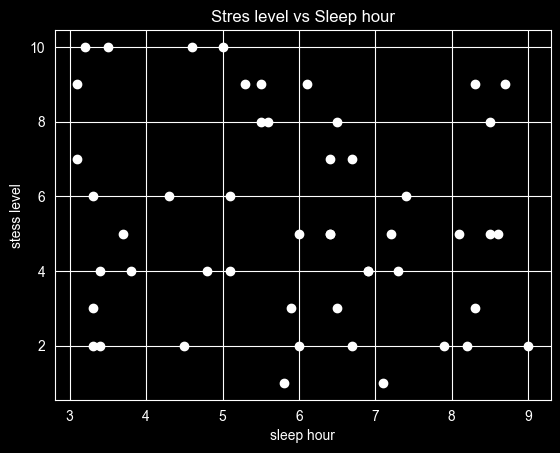

In [67]:
plt.scatter(sleep_hour, stress_level, color='w')

plt.title('Stres level vs Sleep hour')
plt.xlabel("sleep hour")
plt.ylabel("stess level")
plt.xticks(rotation=0)
plt.grid(True)


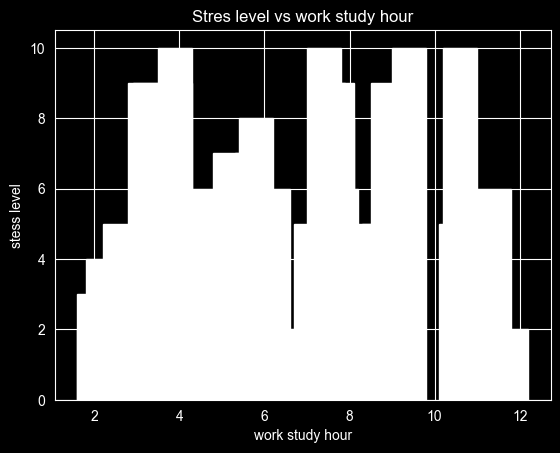

In [68]:
plt.bar(work_study_hours, stress_level, color='w')

plt.title('Stres level vs work study hour')
plt.xlabel("work study hour")
plt.ylabel("stess level")
plt.xticks(rotation=0)
plt.grid(True)

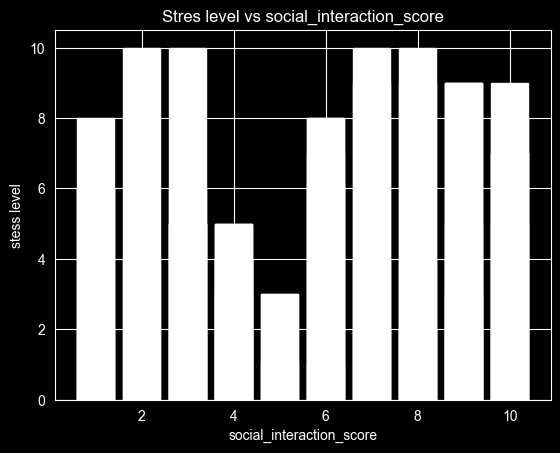

In [69]:
plt.bar(social_interaction_score, stress_level, color='w')

plt.title('Stres level vs social_interaction_score')
plt.xlabel("social_interaction_score")
plt.ylabel("stess level")
plt.xticks(rotation=0)
plt.grid(True)

In [70]:
# encoding data
def encoding(data):
    size_order = [["Low", "Medium", "High"]]
    oe = OrdinalEncoder(categories=size_order)
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    scaler = StandardScaler()

    # transform
    data['Physical_Activity'] = oe.fit_transform(data[['Physical_Activity']])
    encoded_occupation = ohe.fit_transform(data[["Occupation"]])
    encoded_data = pd.DataFrame(encoded_occupation, columns=ohe.get_feature_names_out(['Occupation']))

    data = pd.concat([data, encoded_data], axis=1)
    data = data.drop(columns='Occupation')

    return data

data = encoding(data)
print(data.head(40))


    Age  Daily_Screen_Time  Social_Media_Usage  Night_Usage  Sleep_Hours  \
0    54               10.2                 7.5            0          6.5   
1    44                6.8                 4.5            0          5.1   
2    30                5.5                 6.9            0          3.5   
3    58                5.6                 4.1            0          9.0   
4    23               10.1                 6.0            1          3.8   
5    36                5.3                 6.1            1          3.4   
6    54                4.1                 2.2            0          8.3   
7    34                2.8                 3.5            1          4.8   
8    38                6.7                 5.5            0          6.9   
9    26                6.8                 1.5            0          5.0   
10   26               10.4                 3.5            1          5.3   
11   39                4.2                 4.7            1          4.6   
12   51     

In [71]:
# training the data
X = data.drop(columns=['Stress_Level'])
y = data['Stress_Level']

#splitting to train(80%) and test(20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#model 1
model1 = RandomForestRegressor(random_state=42)
model1.fit(X_train, y_train)
#model 2
model2 = LinearRegression()
model2.fit(X_train, y_train)
#model 3
model3 = DecisionTreeRegressor(random_state=42, max_depth=2)
model3.fit(X_train, y_train)


#predict
prediction1 = model1.predict(X_test)
prediction2 = model2.predict(X_test)
prediction3 = model3.predict(X_test)

# evaluation - comparing both model with the trained model
evaluation_model1 = mean_absolute_error(y_test, prediction1)
evaluation_model2 = mean_absolute_error(y_test, prediction2)
evaluation_model3 = mean_absolute_error(y_test, prediction3)

print(f"The RandomForestRegressor model is off by: {evaluation_model1}")
print(f"The LinearRegression model is off by: {evaluation_model2:.4f}")
print(f"The DecisionTreeRegressor is off by: {evaluation_model3:.4f}")

The RandomForestRegressor model is off by: 2.4297
The LinearRegression model is off by: 2.4066
The DecisionTreeRegressor is off by: 2.3952


In [72]:
# deployment
unseen_data = pd.read_csv('unseen_data.csv')
unseen_data = data_cleaning(unseen_data)
unseen_data = encoding(unseen_data)


# we choose the decisionTreeRegressor modal since it has the lowest error
prediction_newdata = model1.predict(unseen_data)
unseen_data['Predicted stress level'] = prediction_newdata

print(unseen_data)



   Age  Daily_Screen_Time  Social_Media_Usage  Night_Usage  Sleep_Hours  \
0   19                9.2                 1.0            0          6.5   
1   23                4.0                 4.5            0          5.1   
2   30                5.5                 7.0            0          3.5   
3   12                5.6                 4.1            0          9.0   
4   23               10.1                 3.0            1          3.8   
5   19                5.0                 4.2            0          3.3   

   Work_Study_Hours  Physical_Activity  Social_Interaction_Score  Depression  \
0               5.8                0.0                         6           1   
1               7.9                2.0                         5           0   
2               9.4                0.0                         2           1   
3               2.0                2.0                         1           0   
4               4.6                2.0                         4          